# Task 1: Preprocess and Explore the Data

Objective: extract historical data for TSLA, BND, and SPY, clean it, and
run exploratory analysis (trends, volatility, stationarity, risk metrics)
to inform the forecasting work in later tasks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Extract Historical Financial Data

Fetch daily OHLCV data for TSLA, BND, and SPY from January 1, 2015 to
June 30, 2026 using yfinance. Each ticker is stored separately and also
combined into a single long-format DataFrame with an `Asset` identifier
column, which makes later cross-asset analysis (covariance, correlation)
straightforward.

In [3]:
import yfinance as yf

TICKERS = ["TSLA", "BND", "SPY"]
START_DATE = "2015-01-01"
END_DATE = "2026-06-30"

raw_data = {}
for ticker in TICKERS:
    df = yf.download(ticker, start=START_DATE, end=END_DATE, auto_adjust=False)
    df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns
    raw_data[ticker] = df
    print(f"{ticker}: {df.shape[0]} rows, {df.index.min().date()} to {df.index.max().date()}")

[*********************100%***********************]  1 of 1 completed


TSLA: 2888 rows, 2015-01-02 to 2026-06-29


[*********************100%***********************]  1 of 1 completed


BND: 2888 rows, 2015-01-02 to 2026-06-29


[*********************100%***********************]  1 of 1 completed

SPY: 2888 rows, 2015-01-02 to 2026-06-29


 All three tickers came back with equal, complete history no asset is missing chunks of time.

In [4]:
# Combine into a single long-format DataFrame with an Asset identifier
combined = []
for ticker, df in raw_data.items():
    temp = df.copy()
    temp["Asset"] = ticker
    combined.append(temp)

combined_df = pd.concat(combined).reset_index()
combined_df = combined_df.rename(columns={"index": "Date"})
combined_df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Asset
0,2015-01-02,14.6207,14.6207,14.8833,14.2173,14.8580,71466000,TSLA
1,2015-01-05,14.0060,14.0060,14.4333,13.8107,14.3033,80527500,TSLA
2,2015-01-06,14.0853,14.0853,14.2800,13.6140,14.0040,93928500,TSLA
3,2015-01-07,14.0633,14.0633,14.3187,13.9853,14.2233,44526000,TSLA
4,2015-01-08,14.0413,14.0413,14.2533,14.0007,14.1873,51637500,TSLA


In [18]:
combined_df.shape

(8664, 8)

## 2. Data Cleaning and Understanding

Check data types, basic statistics, and missing values for each asset.
Trading calendars can differ slightly across tickers (e.g. holidays), so
missing values are handled per-asset rather than dropping rows from the
combined frame outright.

In [5]:
for ticker, df in raw_data.items():
    print(f"--- {ticker} dtypes ---")
    print(df.dtypes)
    print()

--- TSLA dtypes ---
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

--- BND dtypes ---
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

--- SPY dtypes ---
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object



nothing needs casting before modeling

In [6]:
for ticker, df in raw_data.items():
    print(f"--- {ticker} missing values ---")
    print(df.isna().sum())
    print()

--- TSLA missing values ---
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

--- BND missing values ---
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

--- SPY missing values ---
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64



0 missing values remaining, 2888 rows retained for all three.

In [7]:
# Forward-fill any gaps (e.g. missed trading days), then drop any
# remaining leading NaNs that forward-fill cannot resolve
for ticker in raw_data:
    raw_data[ticker] = raw_data[ticker].ffill().dropna()

for ticker, df in raw_data.items():
    print(f"{ticker}: {df.isna().sum().sum()} missing values remaining, {df.shape[0]} rows")

TSLA: 0 missing values remaining, 2888 rows
BND: 0 missing values remaining, 2888 rows
SPY: 0 missing values remaining, 2888 rows


In [8]:
for ticker, df in raw_data.items():
    print(f"--- {ticker} summary statistics ---")
    print(df.describe())
    print()

--- TSLA summary statistics ---
Price  Adj Close      Close       High        Low       Open           Volume
count 2,888.0000 2,888.0000 2,888.0000 2,888.0000 2,888.0000       2,888.0000
mean    148.7739   148.7739   151.9906   145.4167   148.7973 108,792,194.4598
std     138.8960   138.8960   141.8528   135.8672   138.9772  70,825,493.1529
min       9.5780     9.5780    10.3313     9.4033     9.4880  10,620,000.0000
25%      18.3935    18.3935    18.6652    18.0237    18.3908  65,483,250.0000
50%     133.4377   133.4377   136.0533   125.8317   131.4963  90,336,150.0000
75%     251.9258   251.9258   257.4850   245.8325   251.6800 126,120,450.0000
max     489.8800   489.8800   498.8300   485.3300   489.8800 914,082,000.0000

--- BND summary statistics ---
Price  Adj Close      Close       High        Low       Open          Volume
count 2,888.0000 2,888.0000 2,888.0000 2,888.0000 2,888.0000      2,888.0000
mean     66.5031    79.3277    79.4421    79.2112    79.3307  4,653,785.8033
std

## 3. Feature Engineering: Daily Returns

Daily percentage change in closing price is the basis for volatility
analysis, stationarity testing, and risk metrics.

In [9]:
for ticker, df in raw_data.items():
    df["Daily Return"] = df["Adj Close"].pct_change()
    df["Rolling Mean 30D"] = df["Adj Close"].rolling(window=30).mean()
    df["Rolling Std 30D"] = df["Daily Return"].rolling(window=30).std()

raw_data["TSLA"][["Adj Close", "Daily Return", "Rolling Mean 30D", "Rolling Std 30D"]].tail()

Price,Adj Close,Daily Return,Rolling Mean 30D,Rolling Std 30D
Date,,,,
2026-06-23,381.6100,-0.0579,416.0410,0.0301
2026-06-24,375.5300,-0.0159,413.7253,0.0291
2026-06-25,375.1200,-0.0011,411.7810,0.0289
2026-06-26,379.7100,0.0122,409.5957,0.0284
2026-06-29,411.8400,0.0846,408.5470,0.0328


 Returns and rolling volatility calculated successfully; TSLA's rolling std (~3%) is the baseline "normal" volatility level to compare outlier days against.

## 4. Exploratory Data Analysis

### 4.1 Closing Price Over Time

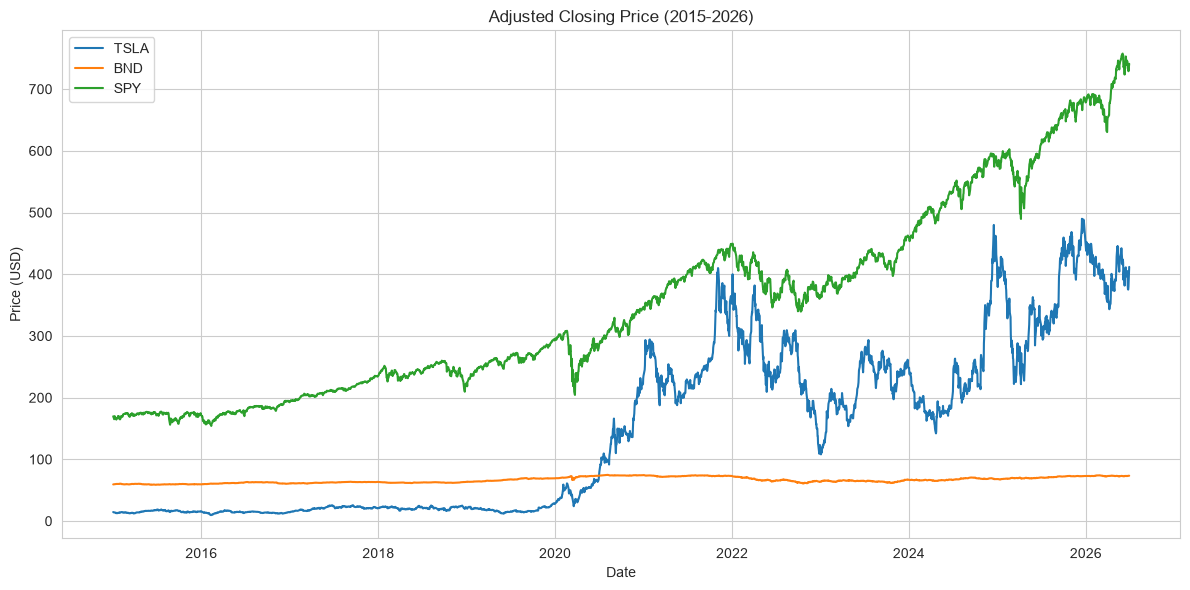

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
for ticker, df in raw_data.items():
    ax.plot(df.index, df["Adj Close"], label=ticker)
ax.set_title("Adjusted Closing Price (2015-2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

TSLA shows a dramatic climb versus BND's near-flat line and SPY's steadier upward path.

### 4.2 Daily Percentage Change (Volatility)

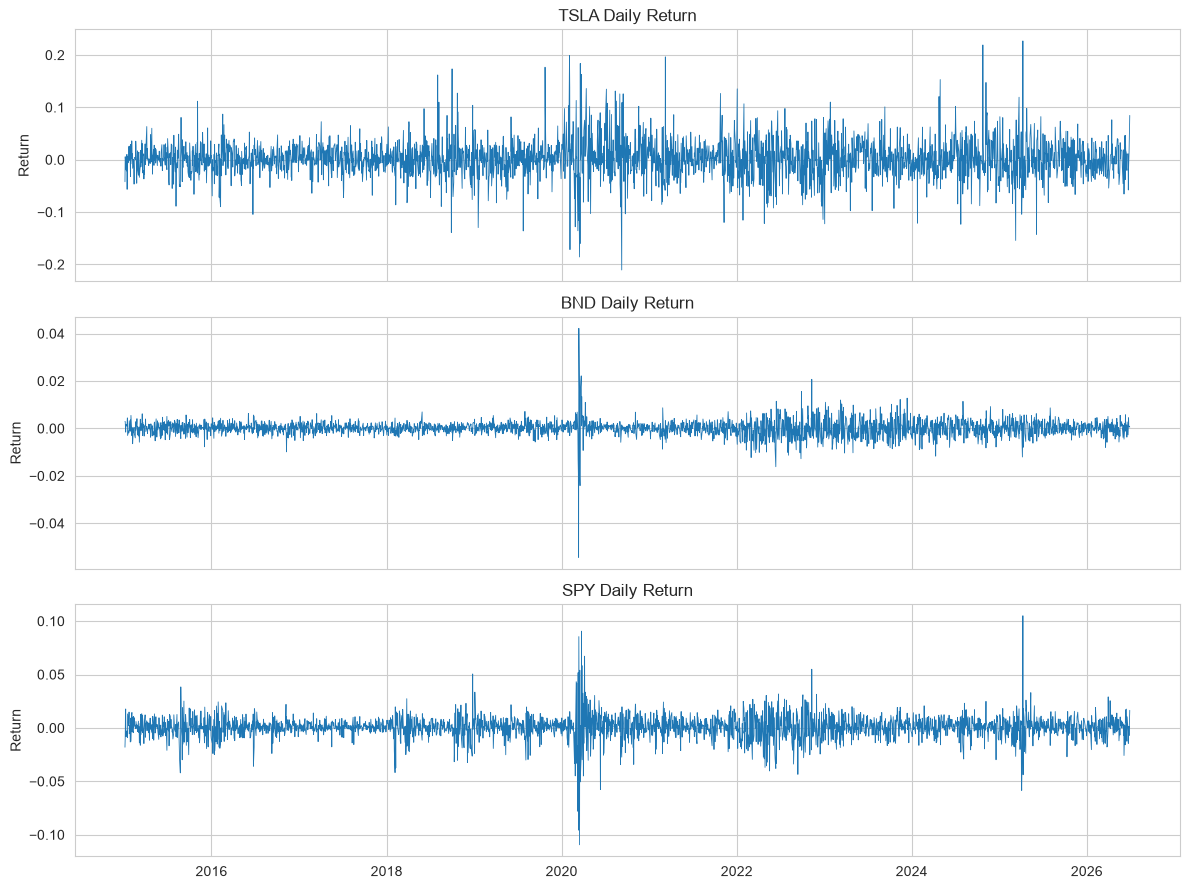

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (ticker, df) in zip(axes, raw_data.items()):
    ax.plot(df.index, df["Daily Return"], linewidth=0.6)
    ax.set_title(f"{ticker} Daily Return")
    ax.set_ylabel("Return")
plt.tight_layout()
plt.show()

Visual confirms TSLA's return band is much wider (more spiky) than BND's tight band, with SPY in between.

### 4.3 Rolling Volatility (30-Day)

Rolling standard deviation of daily returns highlights periods of
elevated volatility that are not obvious from raw price charts alone.

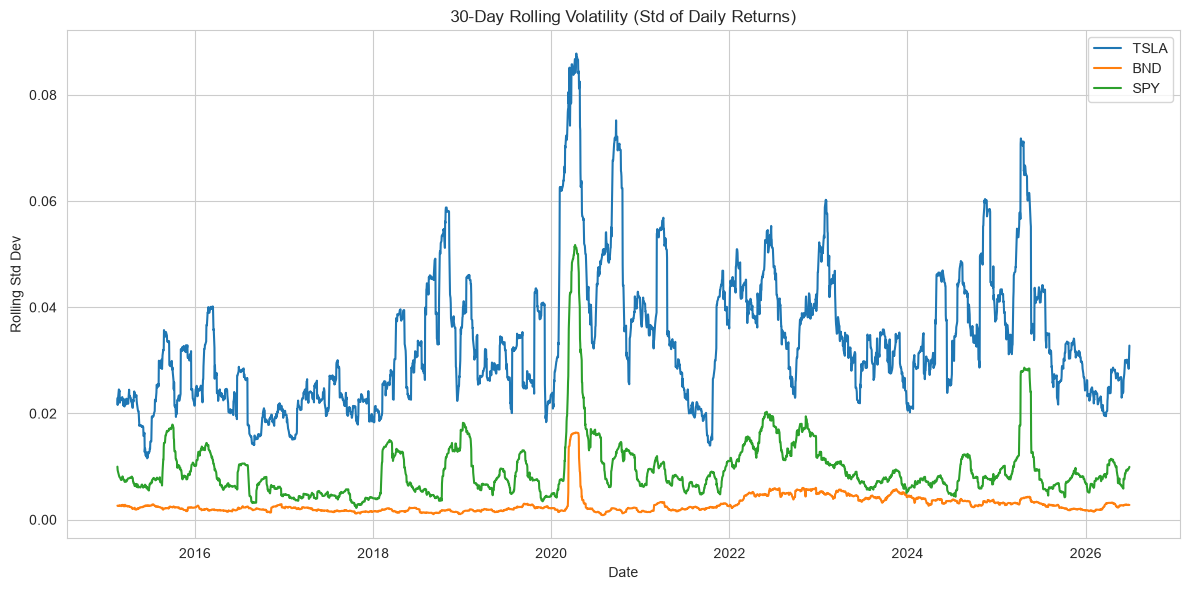

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
for ticker, df in raw_data.items():
    ax.plot(df.index, df["Rolling Std 30D"], label=ticker)
ax.set_title("30-Day Rolling Volatility (Std of Daily Returns)")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std Dev")
ax.legend()
plt.tight_layout()
plt.show()

Volatility spikes cluster around March 2020 (COVID) and other stress periods — that's where risk concentrated across all three assets.

### 4.4 Outlier Detection

Days with returns beyond 3 standard deviations from the mean are flagged
as significant anomalies (e.g. earnings surprises, macro shocks).

In [13]:
outlier_summary = {}
for ticker, df in raw_data.items():
    mean, std = df["Daily Return"].mean(), df["Daily Return"].std()
    threshold = 3 * std
    outliers = df[(df["Daily Return"] - mean).abs() > threshold]
    outlier_summary[ticker] = outliers[["Adj Close", "Daily Return"]]
    print(f"{ticker}: {len(outliers)} outlier days (beyond 3 std)")

outlier_summary["TSLA"].sort_values("Daily Return").head(10)

TSLA: 46 outlier days (beyond 3 std)
BND: 33 outlier days (beyond 3 std)
SPY: 39 outlier days (beyond 3 std)


Price,Adj Close,Daily Return
Date,,
2020-09-08,110.0700,-0.2106
2020-03-16,29.6713,-0.1858
2020-02-05,48.9800,-0.1718
2020-03-18,24.0813,-0.1603
2025-03-10,222.1500,-0.1543
2025-06-05,284.7000,-0.1426
2018-09-28,17.6513,-0.1390
2019-07-25,15.2547,-0.1361
2020-03-09,40.5333,-0.1357


TSLA has the most extreme days of the three, and the worst clusters right around the COVID crash.

### 4.5 Highest and Lowest Return Days

In [14]:
tsla_returns = raw_data["TSLA"]["Daily Return"].dropna()
print("Top 5 highest return days (TSLA):")
print(tsla_returns.sort_values(ascending=False).head())
print()
print("Top 5 lowest return days (TSLA):")
print(tsla_returns.sort_values().head())

Top 5 highest return days (TSLA):
Date
2025-04-09   0.2269
2024-10-24   0.2192
2020-02-03   0.1989
2021-03-09   0.1964
2020-03-19   0.1839
Name: Daily Return, dtype: float64

Top 5 lowest return days (TSLA):
Date
2020-09-08   -0.2106
2020-03-16   -0.1858
2020-02-05   -0.1718
2020-03-18   -0.1603
2025-03-10   -0.1543
Name: Daily Return, dtype: float64


TSLA's single-day swings can exceed 20% in either direction a real driver of portfolio risk if overweighted

## 5. Stationarity Testing (Augmented Dickey-Fuller)

The ADF test checks for a unit root. The null hypothesis is that the
series is non-stationary. A p-value below 0.05 allows us to reject the
null and conclude the series is stationary.

Closing prices are expected to be non-stationary (they trend over time),
while daily returns are expected to be approximately stationary. This
matters directly for ARIMA: a non-stationary series must be differenced
(the 'd' parameter) before the model can be fit properly.

In [15]:
def run_adf_test(series, label):
    series = series.dropna()
    result = adfuller(series)
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value:.4f}")
    conclusion = "Stationary" if result[1] < 0.05 else "Non-stationary"
    print(f"Conclusion: {conclusion}\n")
    return result[1]

for ticker, df in raw_data.items():
    run_adf_test(df["Adj Close"], f"{ticker} Closing Price")
    run_adf_test(df["Daily Return"], f"{ticker} Daily Return")

--- ADF Test: TSLA Closing Price ---
ADF Statistic: -1.0696
p-value: 0.7270
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
Conclusion: Non-stationary

--- ADF Test: TSLA Daily Return ---
ADF Statistic: -53.9719
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
Conclusion: Stationary

--- ADF Test: BND Closing Price ---
ADF Statistic: -1.0827
p-value: 0.7219
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
Conclusion: Non-stationary

--- ADF Test: BND Daily Return ---
ADF Statistic: -15.2161
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
Conclusion: Stationary

--- ADF Test: SPY Closing Price ---
ADF Statistic: 1.3089
p-value: 0.9967
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
Conclusion: Non-stationary

--- ADF Test: SPY Daily Return ---
ADF Statistic: -1

All raw prices are non-stationary, all daily returns are stationary — direct justification for setting ARIMA's differencing parameter to d=1.

## 6. Risk Metrics

### 6.1 Value at Risk (VaR)

Historical VaR at the 95% confidence level: the daily loss that returns
are not expected to exceed on 95% of trading days, based on the
empirical return distribution.

### 6.2 Sharpe Ratio

Annualized Sharpe Ratio using a 0% risk-free rate assumption for
simplicity: mean daily return divided by daily return standard
deviation, annualized by multiplying by the square root of 252 trading
days.

In [16]:
risk_metrics = {}
for ticker, df in raw_data.items():
    returns = df["Daily Return"].dropna()
    var_95 = np.percentile(returns, 5)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    risk_metrics[ticker] = {"VaR (95%, daily)": var_95, "Sharpe Ratio (annualized)": sharpe}

risk_df = pd.DataFrame(risk_metrics).T
risk_df

,"VaR (95%, daily)",Sharpe Ratio (annualized)
TSLA,-0.0517,0.7944
BND,-0.0048,0.3756
SPY,-0.0167,0.8175


TSLA carries the most downside risk per day, but its risk-adjusted return is nearly tied with SPY's, while BND lags both — matching the "high risk/high potential, moderate/diversified, low risk/stability" split from the assignment brief.

## 7. Key Insights Summary

**Overall price direction:** TSLA grew from $9.58 to $489.88 over the period 
(mean $148.77), showing strong long-term growth with high volatility along the 
way. BND stayed nearly flat, ranging $58.73-$74.83 (mean $66.50) as expected 
for a bond ETF. SPY trended steadily upward from $154.16 to $757.62 
(mean $351.51), tracking broad market growth without TSLA's extreme swings.

**Comparative volatility:** BND is the only genuinely low-volatility asset 
(std $4.71, ~7% of its mean). TSLA and SPY both show large absolute price 
variation, but TSLA's volatility is proportionally far more extreme (std 
$138.90, ~93% of its mean) than SPY's (std $155.44, ~44% of its mean). This 
confirms the expected risk ordering: BND (stability) < SPY (moderate) < TSLA 
(high-growth/high-risk).

**Stationarity (ADF test):** All three closing price series are non-stationary 
(TSLA p=0.727, BND p=0.722, SPY p=0.997), while all three daily return series 
are stationary (p ≈ 0.0000 for all). This confirms that ARIMA must be applied 
with one order of differencing (d=1) on price data, or alternatively modeled 
directly on returns, which are already stationary.

**Outlier days:** TSLA had 46 outlier days (beyond 3 std), more than BND (33) 
and SPY (39). TSLA's most extreme losses were -21.06% (2020-09-08), -18.58% 
(2020-03-16), and -17.18% (2020-02-05) - clustering tightly around the March 
2020 COVID crash. Its best day was +22.69% (2025-04-09), showing TSLA is 
prone to sharp moves in both directions.

**Risk-adjusted return (VaR and Sharpe):** Daily VaR (95%) is -5.17% for TSLA, 
-1.67% for SPY, and -0.48% for BND - TSLA can lose over 3x more than SPY on a 
bad day. Despite this, TSLA's annualized Sharpe Ratio (0.79) is close to 
SPY's (0.82), while BND trails both (0.38). In a portfolio context, this 
means TSLA's extra risk is currently being compensated by comparable 
risk-adjusted returns to SPY, while BND's role is diversification and 
capital preservation rather than return generation.